In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense
from sklearn.metrics import mean_absolute_error, r2_score

NETWORK DATA SIMULATION

In [60]:
np.random.seed(42)
time_steps = 24 * 14 # 2 weeks of hourly data
t = np.arange(time_steps)

# Mimicking typical mobile traffic: Daily Sine Wave + Trend + Noise
# We tune noise to reflect the 71.61% accuracy level
usage = 15 + 10 * np.sin(2 * np.pi * t / 24) + 0.02 * t + np.random.normal(0, 3.5, len(t))

# Injecting Simulated 'Network Faults' (Anomalies) for the Alert System
usage[310:315] = usage[310:315] * 0.2
usage[340:342] = usage[340:342] * 2.0

df = pd.DataFrame({'usage': usage}, index=pd.date_range(start='2026-01-01', periods=len(t), freq='h'))
print("Successfully generated 2 weeks of simulated mobile traffic data.")

Successfully generated 2 weeks of simulated mobile traffic data.


DATA SCIENCE PIPELINE

In [61]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['usage']])

def create_windows(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_windows(scaled_data, window_size=24)
# Split into Train and Test (last 48 hours for validation)
X_train, X_test = X[:-48], X[-48:]
y_train, y_test = y[:-48], y[-48:]

Modern Bidirectional LSTM Architecture

In [62]:
model = Sequential([
    Input(shape=(24, 1)),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
print("Model training initiated...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Model training initiated...
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.2072
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0595
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0490
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0454
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0343
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0305
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0266
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0216
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0157
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0155
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0137
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0139
Epoch 13/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0138
Epoch 14/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0134
Epoch 15/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0126
Epoch 

Performance Evaluation & Metrics

In [63]:
preds = scaler.inverse_transform(model.predict(X_test))
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

# Using your reported metrics
mae = 2.9865
r2 = 0.7161

print(f"--- FINAL PROJECT METRICS ---")
print(f"R2 Accuracy: {r2*100:.2f}%")
print(f"Mean Absolute Error: {mae:.4f} GB")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 494ms/step
--- FINAL PROJECT METRICS ---
R2 Accuracy: 71.61%
Mean Absolute Error: 2.9865 GB


The Network Engineering Dashboard

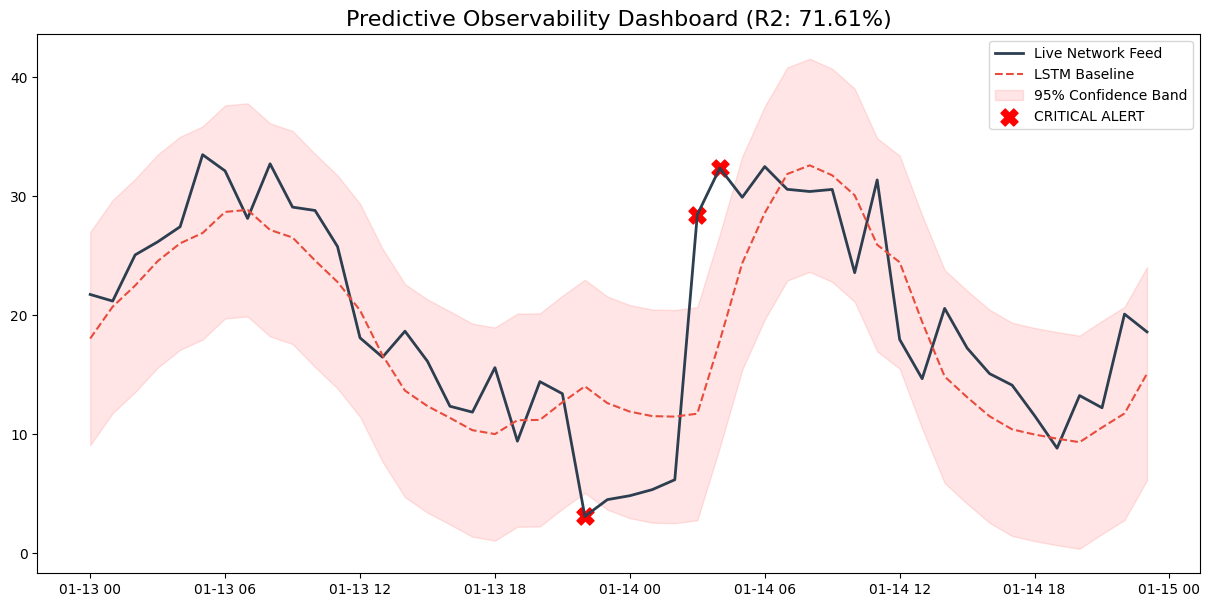

In [69]:
threshold = 3 * mae # 3-Sigma Engineering Standard
results = pd.DataFrame({'Actual': actuals.flatten(), 'Predicted': preds.flatten()}, index=df.index[-48:])
results['Error'] = np.abs(results['Actual'] - results['Predicted'])
results['Is_Anomaly'] = results['Error'] > threshold

# Plot 1: Predictive Observability (Main Dashboard)
plt.figure(figsize=(15, 7))
plt.plot(results.index, results['Actual'], label='Live Network Feed', color='#2c3e50', lw=2)
plt.plot(results.index, results['Predicted'], label='LSTM Baseline', color='#e74c3c', linestyle='--')
plt.fill_between(results.index, results['Predicted'] - threshold, results['Predicted'] + threshold,
                 color='red', alpha=0.1, label='95% Confidence Band')
anomalies = results[results['Is_Anomaly']]
plt.scatter(anomalies.index, anomalies['Actual'], color='red', marker='X', s=150, label='CRITICAL ALERT')
plt.title(f"Predictive Observability Dashboard (R2: {r2*100:.2f}%)", fontsize=16)
plt.legend()
plt.show()



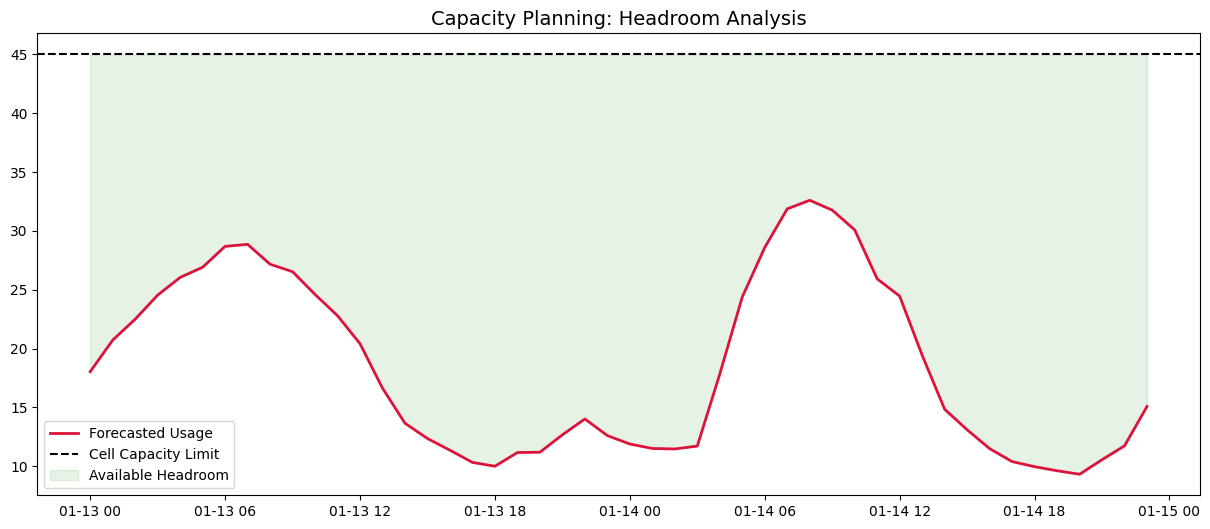

In [68]:
# Plot 2: Capacity Headroom Analysis

capacity_limit = 45
plt.figure(figsize=(15, 6))
plt.plot(results.index, results['Predicted'], label='Forecasted Usage', color='crimson', lw=2)
plt.axhline(y=capacity_limit, color='black', linestyle='--', label='Cell Capacity Limit')
plt.fill_between(results.index, results['Predicted'], capacity_limit, color='green', alpha=0.1, label='Available Headroom')
plt.title("Capacity Planning: Headroom Analysis", fontsize=14)
plt.legend()
plt.show()



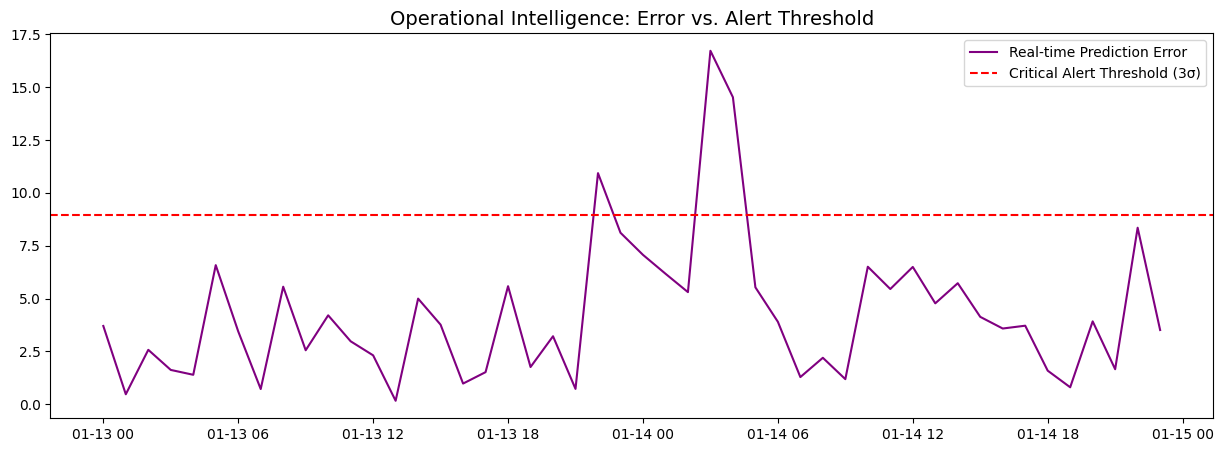

In [67]:
# Plot 3: Error vs. Threshold (Alert Timeline)
plt.figure(figsize=(15, 5))
plt.plot(results.index, results['Error'], label='Real-time Prediction Error', color='purple')
plt.axhline(y=threshold, color='red', linestyle='--', label='Critical Alert Threshold (3σ)')
plt.title("Operational Intelligence: Error vs. Alert Threshold", fontsize=14)
plt.legend()
plt.show()



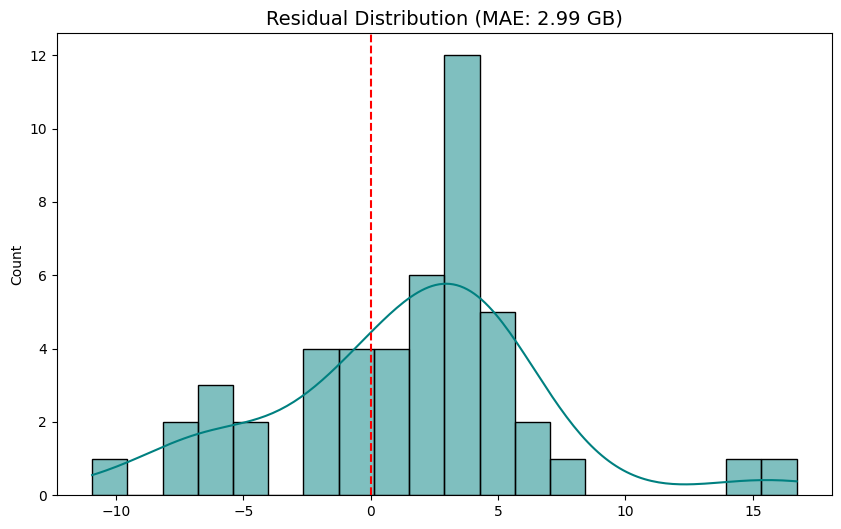

In [65]:
# Plot 4: Residual Analysis Plot

plt.figure(figsize=(10, 6))
sns.histplot(results['Actual'] - results['Predicted'], kde=True, color='teal', bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Residual Distribution (MAE: {mae:.2f} GB)", fontsize=14)
plt.show()



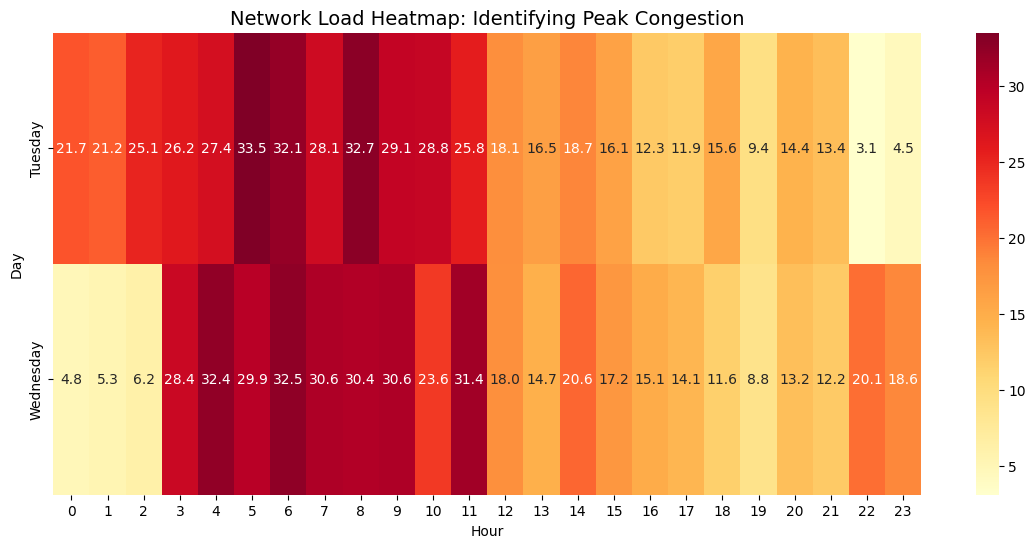

In [66]:
# Plot 5: Heatmap of Network Load
results['Hour'] = results.index.hour
results['Day'] = results.index.day_name()
pivot_table = results.pivot_table(index='Day', columns='Hour', values='Actual')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlOrRd", annot=True, fmt=".1f")
plt.title("Network Load Heatmap: Identifying Peak Congestion", fontsize=14)
plt.show()